---

## Module 6 — Parallel Workflows in LangGraph

Two examples in this module — a simple non-LLM parallel workflow to learn the syntax, then an LLM-based one.

---

### 🏏 Workflow 1 — Batsman Stats Calculator

A cricket innings analyzer where three stats are independent of each other and can be calculated simultaneously — a perfect use case for parallelism.

**Flow:**
```
START
  ↓
[calculate_sr] [calculate_bpb] [calculate_boundary_percent]  ← parallel
  ↓
[summary]
  ↓
END
```

> 📌 *These three nodes don't depend on each other's output — all three read from the same input fields in State and write to different fields. That's the signal to run them in parallel.*

---

#### State

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
class BatsmanState(TypedDict):
    # inputs
    runs: int
    balls: int
    fours: int
    sixes: int
    # calculated outputs
    sr: float               # strike rate
    bpb: float              # balls per boundary
    boundary_percent: float # % of runs scored in boundaries
    summary: str            # final aggregated summary

---

#### Nodes

In [4]:
def calculate_sr(state: BatsmanState):
    """Calculate strike rate: runs scored per 100 balls faced."""
    sr = (state['runs'] / state['balls']) * 100
    return {'sr': sr}  # partial state update

def calculate_bpb(state: BatsmanState):
    """Calculate balls per boundary: how often the batsman hits a boundary."""
    bpb = state['balls'] / (state['fours'] + state['sixes'])
    return {'bpb': bpb}  # partial state update

def calculate_boundary_percent(state: BatsmanState):
    """Calculate percentage of total runs scored through boundaries."""
    boundary_runs = (state['fours'] * 4) + (state['sixes'] * 6)
    boundary_percent = (boundary_runs / state['runs']) * 100
    return {'boundary_percent': boundary_percent}  # partial state update

def summary(state: BatsmanState):
    """Aggregate all calculated stats into a readable summary string."""
    summary = f"""
Strike Rate - {state['sr']}
Balls per boundary - {state['bpb']}
Boundary percent - {state['boundary_percent']}
"""
    return {'summary': summary}

> 📌 *Each parallel node returns only the field it calculated — not the entire State. This is called a **partial state update**. If you return the full State from parallel nodes, LangGraph throws an `InvalidUpdateError` because it sees conflicting updates to shared fields (like `runs`, `balls`) from multiple nodes simultaneously.*

> 💡 *Best practice: always use partial state updates (return a dict with only changed keys) in both sequential and parallel workflows — it works correctly in both cases.*

---

#### Graph

In [5]:
graph = StateGraph(BatsmanState)

# register nodes
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

# fan-out: START triggers all three parallel nodes simultaneously
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

# fan-in: all three parallel nodes feed into summary
graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

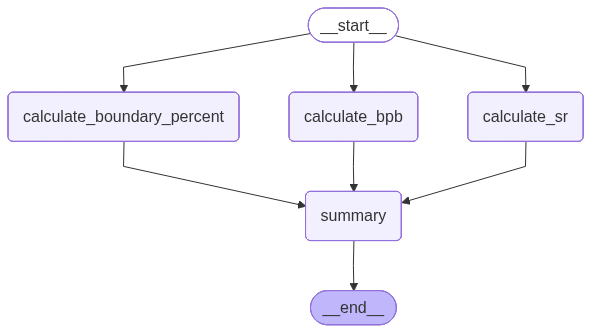

In [6]:
workflow

> 📌 *Parallelism in LangGraph is just edges — add multiple edges from the same source node to trigger parallel execution. No special syntax needed. The fan-out (START → 3 nodes) and fan-in (3 nodes → summary) pattern is how you structure any parallel workflow.*

---

#### Run

In [7]:
initial_state = {'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4}
workflow.invoke(initial_state)

# Output:
# sr: 200.0, bpb: 5.0, boundary_percent: 48.0
# summary: Strike Rate - 200.0 | Balls per boundary - 5.0 | Boundary percent - 48.0

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\nStrike Rate - 200.0\nBalls per boundary - 5.0\nBoundary percent - 48.0\n'}

---

### 📝 Workflow 2 — UPSC Essay Evaluator (LLM-Based Parallel)

A real-world parallel workflow combining three concepts together: parallel execution, structured output, and reducers.

**Flow:**
```
START
  ↓
[evaluate_language] [evaluate_analysis] [evaluate_thought]  ← parallel LLM calls
  ↓
[final_evaluation]  ← summarizes feedback + calculates avg score
  ↓
END
```

---

#### Setup

In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

load_dotenv(override=True)

model = ChatOpenAI(model='gpt-4o-mini')

---

#### Structured Output Schema

The three parallel evaluation nodes each need to return two things — a textual feedback and a numeric score. If we just prompt the LLM freely, it might return "seven" instead of `7`, breaking downstream calculations. Structured output solves this by enforcing a strict response schema every time.

In [9]:
class EvaluationSchema(BaseModel):
    """Schema to enforce consistent LLM output format for essay evaluation."""
    feedback: str = Field(description='Detailed feedback for the essay')
    score: int = Field(description='Score out of 10', ge=0, le=10)  # ge/le enforce valid range

# bind schema to model — now every response is guaranteed to match EvaluationSchema
structured_model = model.with_structured_output(EvaluationSchema)

> 📌 *`with_structured_output()` is a LangChain method — another example of LangChain and LangGraph working hand in hand. LangGraph handles the workflow orchestration; LangChain provides the LLM components.*

**Testing structured model standalone before building the workflow:**

In [10]:
essay = """India in the Age of AI
As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.

India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.

One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.

However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.

Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.

To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.

India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.

In conclusion, India in the age of AI is a story in the making — one of opportunity, responsibility, and transformation. The decisions we make today will not just determine India’s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society."""


In [11]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'

output = structured_model.invoke(prompt)

print(output.feedback)  # returns textual feedback string
print(output.score)    # returns integer score e.g. 8

The essay presents a coherent and well-structured argument regarding India's position in the artificial intelligence landscape. The language is formal and appropriate for an academic context, demonstrating a good command of vocabulary and grammar. The introduction effectively sets the stage for the discussion, while the body paragraphs provide a balanced view of both the opportunities and challenges associated with AI in India. The use of specific examples enhances the credibility of the claims made, particularly regarding the contributions of educational institutions and the potential applications of AI in various sectors.

However, there are areas for improvement. There is a slight repetitiveness in some phrases that could be varied for greater engagement, and the connection between the challenges and opportunities could be further emphasized to create a more interconnected narrative. Additionally, while the essay touches upon ethical and socio-economic concerns, it could benefit fro

> 📌 *Always test your LLM components in isolation before wiring them into a graph. It confirms the structured output is working as expected before adding workflow complexity.*

---

#### State

In [12]:
import operator
from typing import TypedDict, Annotated

class UPSCState(TypedDict):
    essay: str                # input — essay text to evaluate
    language_feedback: str    # set by evaluate_language node
    analysis_feedback: str    # set by evaluate_analysis node
    clarity_feedback: str     # set by evaluate_thought node
    overall_feedback: str     # set by final_evaluation node
    individual_scores: Annotated[list[int], operator.add]  # reducer — merges scores from parallel nodes
    avg_score: float          # final average computed in final_evaluation

> 📌 *`Annotated[list[int], operator.add]` is the reducer at work. The three parallel nodes each return `[score]` — a single-element list. Without the reducer, each would overwrite the previous value (default replace behaviour). With `operator.add`, LangGraph merges them: `[7] + [8] + [8]` → `[7, 8, 8]`. This is equivalent to Python's `+` operator on lists.*

> 💡 *Why wrap scores in a list `[output.score]` instead of just `output.score`? Because `operator.add` works on lists — it concatenates them. A bare integer would cause a type error.*

---

#### Nodes

In [13]:
def evaluate_language(state: UPSCState):
    """Evaluate language quality of the essay — returns feedback and score."""
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)
    # wrap score in list so reducer can concatenate with scores from other parallel nodes
    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_analysis(state: UPSCState):
    """Evaluate depth of analysis of the essay — returns feedback and score."""
    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)
    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_thought(state: UPSCState):
    """Evaluate clarity of thought of the essay — returns feedback and score."""
    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)
    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

def final_evaluation(state: UPSCState):
    """Aggregate all three feedbacks into a summary and compute the average score."""
    # use normal model here — we only need plain text, not structured output
    # using structured_model would force an unnecessary schema and might generate an extra score
    prompt = f"""Based on the following feedbacks create a summarized feedback
    \n language feedback - {state["language_feedback"]}
    \n depth of analysis feedback - {state["analysis_feedback"]}
    \n clarity of thought feedback - {state["clarity_feedback"]}"""
    overall_feedback = model.invoke(prompt).content

    # by this point reducer has merged all three scores into one list e.g. [7, 8, 8]
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

---

#### Graph

In [14]:
graph = StateGraph(UPSCState)

# register all four nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# fan-out: START triggers all three evaluation nodes simultaneously
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

# fan-in: all three completed nodes feed into final_evaluation
graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

---

#### Run

In [15]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

In [16]:
# well-written essay
initial_state = {'essay': essay}
workflow.invoke(initial_state)
# individual_scores: [7, 8, 8] → avg_score: 7.67

# intentionally poor essay (bad grammar, weak arguments)
initial_state = {'essay': essay2}
workflow.invoke(initial_state)
# individual_scores: [2, 3, 2] → avg_score: 2.33

{'essay': 'India and AI Time\n\nNow world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.\n\nIndia have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.\n\nIn farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.\n\nBut problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.\n\nOne more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.\n\n

> 📌 *Testing with two contrasting essays validates that the workflow is actually evaluating correctly — a good essay scores high, a poor one scores low.*

---

#### 🔑 Three Concepts in One Workflow

| Concept | Where used | Why needed |
|---|---|---|
| **Parallel execution** | 3 evaluation nodes run simultaneously | Each aspect is independent — no need to wait |
| **Structured output** | `EvaluationSchema` + `with_structured_output()` | Guarantees reliable `feedback` + `score` every time |
| **Reducer** | `Annotated[list[int], operator.add]` | Merges 3 parallel scores into one list without overwriting |

---

